# Data & AI Compensation Benchmark - Análisis Exploratorio

## Objetivo

¿Qué factores explican la compensación de profesionales de datos e IA a nivel global, y qué tan defendibles son esas diferencias dado el tamaño real de la muestra? El análisis está pensado para dos audiencias: un equipo de **RR. HH.** evaluando competitividad salarial, y un **profesional de datos/IA** decidiendo en qué especializarse.

## Preguntas clave

- ¿Qué roles/especializaciones tienen los salarios más altos?
- ¿Cómo influye la experiencia, y es una diferencia real o ruido de muestra?
- ¿Qué países pagan mejor, una vez controlado el tamaño de muestra y el poder adquisitivo?
- ¿Qué otras variables (tamaño de empresa, modalidad remota) impactan el salario?

## Tabla de contenidos

- [Objetivo](#Objetivo)
- [Preguntas clave](#Preguntas-clave)
- [Carga de datos](#Carga-de-datos)
- [Vista general del dataset](#Vista-general-del-dataset)
- [Distribución del salario](#Distribución-del-salario)
- [Salario por nivel de experiencia](#Salario-por-nivel-de-experiencia)
- [Salario por rol](#Salario-por-rol)
- [Top países mejor pagados](#Top-países-mejor-pagados)
- [Relación experiencia vs. salario](#Relación-experiencia-vs.-salario)
- [Heatmap de correlación](#Heatmap-de-correlación)
- [Impacto del tipo de empleo](#Impacto-del-tipo-de-empleo)
- [Rigor estadístico: ¿las diferencias son reales o ruido de muestra?](#Rigor-estadístico:-¿las-diferencias-son-reales-o-ruido-de-muestra?)
- [Conclusiones y recomendaciones de negocio](#Conclusiones-y-recomendaciones-de-negocio)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Carga de datos

Se carga el resultado del pipeline de ETL (`src/etl.py`), ya limpio, filtrado a roles de datos/IA y enriquecido con categoría de rol, continente y salario ajustado por poder adquisitivo.

In [2]:
df = pd.read_csv("../data/processed/compensation.csv", index_col=0)
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_usd,employee_residence,remote_ratio,company_location,company_size,salary_category,job_category,continent,salary_usd_ppp
0,2025,Executive,Full-time,Head of Data,348516,USD,348516,US,0,US,M,High,Data Leadership,North America,348516.0
1,2025,Executive,Full-time,Head of Data,232344,USD,232344,US,0,US,M,High,Data Leadership,North America,232344.0
2,2025,Senior,Full-time,Data Scientist,145400,USD,145400,US,0,US,M,High,Data Scientist,North America,145400.0
3,2025,Senior,Full-time,Data Scientist,81600,USD,81600,US,0,US,M,Medium,Data Scientist,North America,81600.0
6,2025,Senior,Full-time,AI Product Lead,175000,USD,175000,US,100,US,M,High,Data Leadership,North America,175000.0


## Vista general del dataset

Antes de analizar, se revisa la estructura del dataset: tipos de dato, completitud y estadísticas descriptivas generales.

In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 85088 entries, 0 to 151444
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   work_year           85088 non-null  int64  
 1   experience_level    85088 non-null  str    
 2   employment_type     85088 non-null  str    
 3   job_title           85088 non-null  str    
 4   salary              85088 non-null  int64  
 5   salary_currency     85088 non-null  str    
 6   salary_usd          85088 non-null  int64  
 7   employee_residence  85088 non-null  str    
 8   remote_ratio        85088 non-null  int64  
 9   company_location    85088 non-null  str    
 10  company_size        85088 non-null  str    
 11  salary_category     85088 non-null  str    
 12  job_category        85088 non-null  str    
 13  continent           85088 non-null  str    
 14  salary_usd_ppp      85078 non-null  float64
dtypes: float64(1), int64(4), str(10)
memory usage: 10.4 MB


In [4]:
df.describe()

,work_year,salary,salary_usd,remote_ratio,salary_usd_ppp
count,85088.000000,8.508800e+04,85088.000000,85088.000000,8.507800e+04
mean,2024.286315,1.553477e+05,149402.741303,23.931694,1.527791e+05
std,0.749383,2.324883e+05,70674.386952,42.564866,7.303012e+04
min,2020.000000,1.400000e+04,15000.000000,0.000000,1.788800e+04
25%,2024.000000,1.000000e+05,100000.000000,0.000000,1.030000e+05
50%,2024.000000,1.400000e+05,140000.000000,0.000000,1.419747e+05
75%,2025.000000,1.870000e+05,185900.000000,0.000000,1.890000e+05
max,2025.000000,3.040000e+07,800000.000000,100.000000,1.557129e+06


## Distribución del salario

Punto de partida del análisis: ¿cómo se distribuye `salary_usd` antes de segmentar por cualquier otra variable?

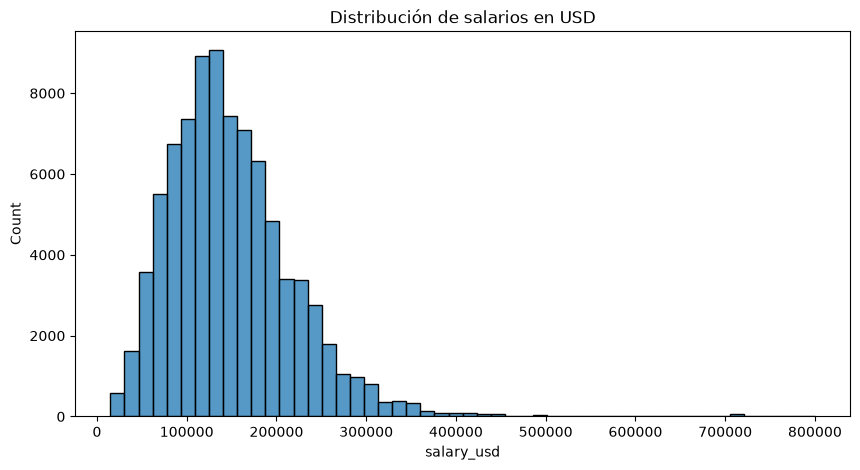

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df["salary_usd"], bins=50)
plt.title("Distribución de salarios en USD")
plt.show()

La distribución está sesgada a la derecha (media de $149,403 por encima de la mediana de $140,000): la mayoría de los salarios se concentra entre $100,000 y $186,000 (percentiles 25 y 75), con una cola de valores altos que llega hasta $800,000. Ese sesgo es la razón por la que, más adelante, se usan pruebas no paramétricas en vez de asumir una distribución normal.

## Salario por nivel de experiencia

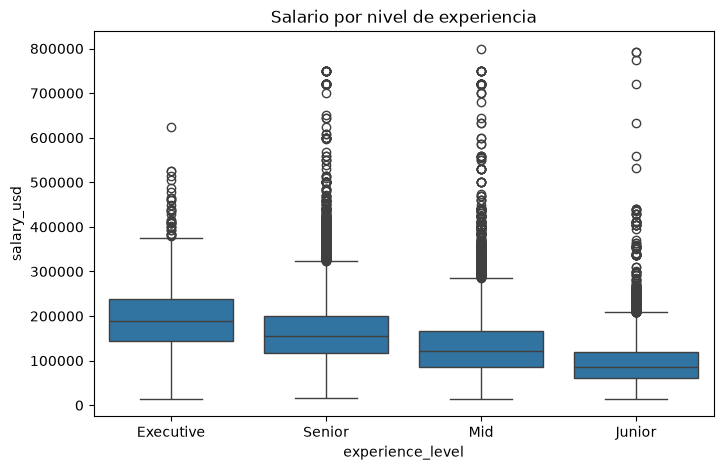

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="experience_level", y="salary_usd", data=df)
plt.title("Salario por nivel de experiencia")
plt.show()

El salario mediano crece de forma consistente con la experiencia: $85,000 (Junior) → $121,600 (Mid) → $156,400 (Senior) → $188,400 (Executive). La dispersión también se reduce en los niveles intermedios, aunque vuelve a ampliarse en Executive por el menor tamaño de muestra de ese grupo (1,999 filas). La sección de rigor estadístico más adelante confirma que estas diferencias no son producto del azar.

## Salario por rol

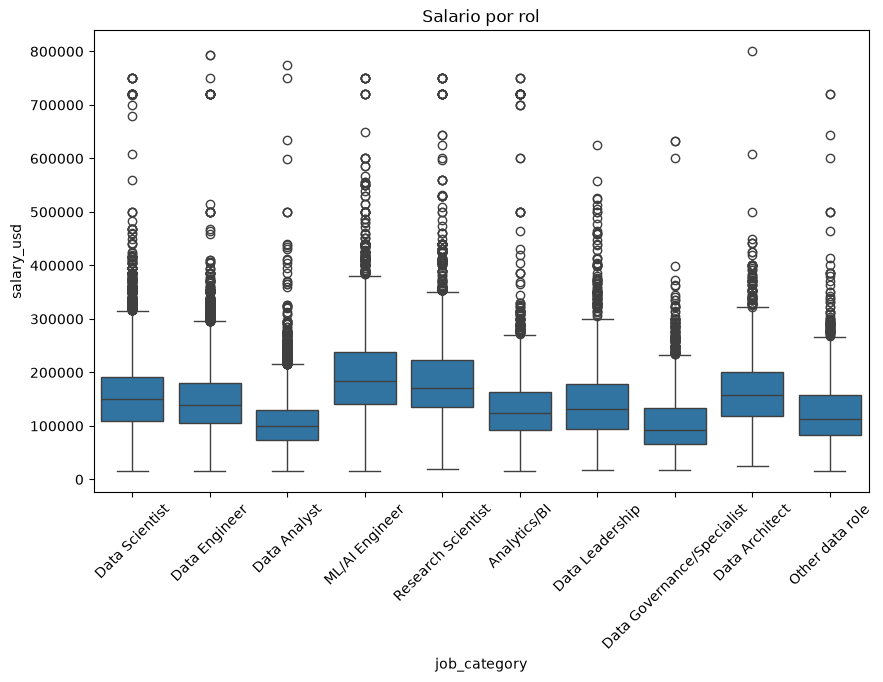

In [7]:
top_roles = df["job_category"].value_counts().index  # categorizar en el etl

plt.figure(figsize=(10, 6))
sns.boxplot(x="job_category", y="salary_usd", data=df, order=top_roles)
plt.xticks(rotation=45)
plt.title("Salario por rol")
plt.show()

**ML/AI Engineer** es, en promedio, la categoría mejor pagada, seguida de **Research Scientist** y **Data Architect**. **Data Analyst** y **Data Governance/Specialist** quedan en el extremo opuesto. La sección de conclusiones retoma este ranking con el desglose exacto por categoría y su lectura para candidatos evaluando en qué especializarse.

## Top países mejor pagados

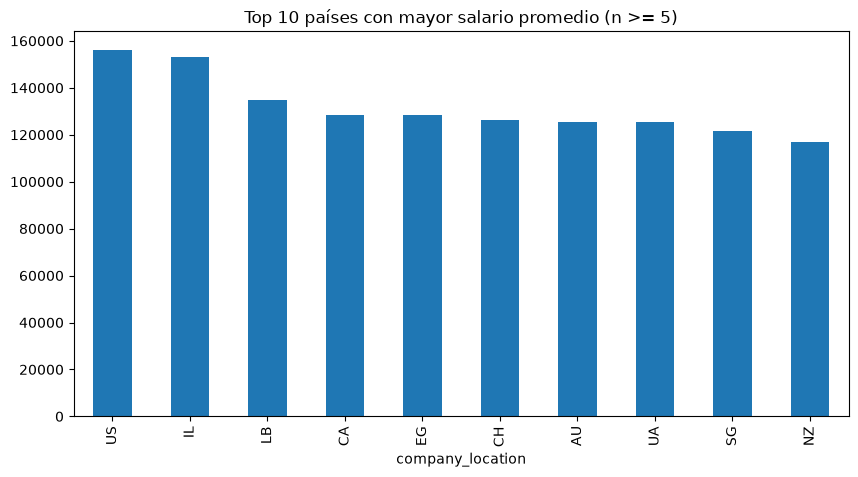

In [8]:
country_counts = df["company_location"].value_counts()
paises_con_muestra_minima = country_counts[country_counts >= 5].index  # ver sección de rigor estadístico

top_countries = (
    df[df["company_location"].isin(paises_con_muestra_minima)]
    .groupby("company_location")["salary_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
top_countries.plot(kind="bar")
plt.title("Top 10 países con mayor salario promedio (n >= 5)")
plt.show()

Incluso con el piso de 5 observaciones, varios de estos países tienen muestras pequeñas (Israel, Líbano, Ucrania) frente a Estados Unidos (decenas de miles de filas). La sección de rigor estadístico cuantifica esa incertidumbre con intervalos de confianza antes de sacar conclusiones sobre qué país "paga mejor".

## Relación experiencia vs. salario

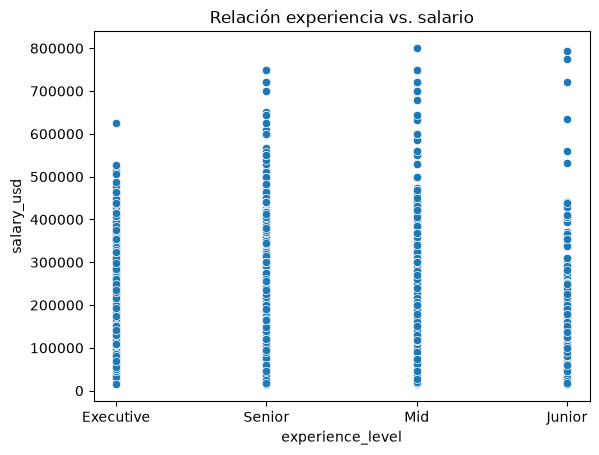

In [9]:
sns.scatterplot(x="experience_level", y="salary_usd", data=df)
plt.title("Relación experiencia vs. salario")
plt.show()

La dispersión confirma un orden monótono y esperable: Executive ($188,400 de mediana) > Senior ($156,400) > Mid ($121,600) > Junior ($85,000). A diferencia de lo que sugería una muestra más pequeña en versiones anteriores de este análisis, Executive ya no queda por debajo de Senior — con más datos, la jerarquía de experiencia se refleja con claridad en la compensación.

## Heatmap de correlación

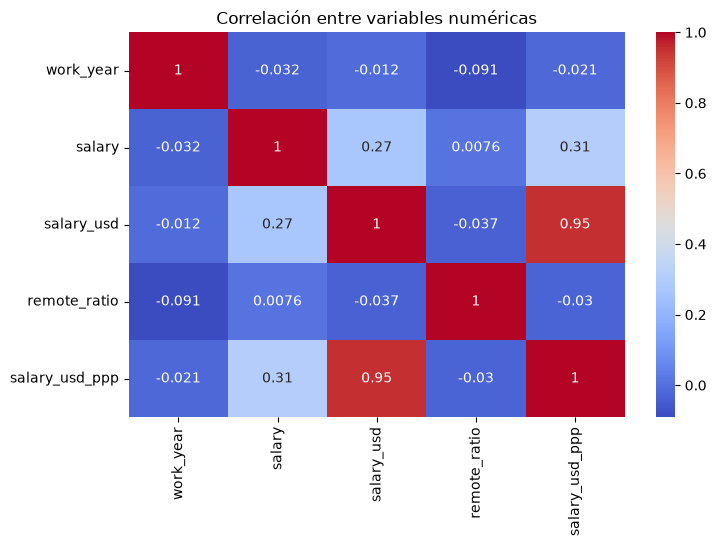

In [10]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlación entre variables numéricas")
plt.show()

- `salary_usd` y `salary_usd_ppp` correlacionan en 0.95, pero es un resultado esperado y no un hallazgo: la segunda se calcula a partir de la primera (ver [Fuentes de Datos y Créditos](../README.md#fuentes-de-datos-y-créditos) en el README).
- `remote_ratio` prácticamente no correlaciona con el salario (-0.04): la modalidad remota, por sí sola, no es un predictor lineal de compensación.
- `work_year` tampoco muestra correlación lineal (-0.01) porque la relación no es monótona: el salario promedio subió de $102,251 (2020) a $153,965 (2023) y luego se estabilizó/retrocedió levemente a $146,315 (2025) — una correlación lineal no captura ese quiebre de tendencia.
- En general, ninguna variable numérica por sí sola explica el salario de forma fuerte: como muestra el resto del notebook, la compensación depende de la combinación de rol, experiencia y ubicación, no de una sola variable aislada.

## Impacto del tipo de empleo

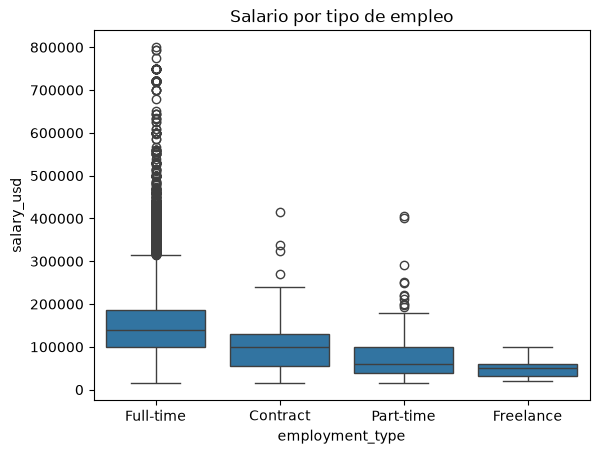

In [11]:
sns.boxplot(x="employment_type", y="salary_usd", data=df)
plt.title("Salario por tipo de empleo")
plt.show()

El empleo Full-time domina de forma casi absoluta el mercado de datos/IA (99.3% de las filas, $149,809 de salario promedio), muy por delante de Contract (0.4%, $102,469), Part-time (0.3%, $78,320) y Freelance (0.04%, $50,253). Con muestras tan pequeñas para las otras tres modalidades, cualquier comparación entre ellas debe leerse como orientativa, no concluyente.

## Rigor estadístico: ¿las diferencias son reales o ruido de muestra?

Los gráficos anteriores muestran diferencias visuales entre grupos, pero no dicen si esas diferencias son estadísticamente significativas o si podrían deberse al azar dado el tamaño de cada grupo. Antes de elegir una prueba, se revisa la forma de la distribución de `salary_usd`.

In [12]:
from scipy import stats

print("Asimetría (skew) de salary_usd:", df["salary_usd"].skew())

Asimetría (skew) de salary_usd: 1.4743952401624143


Un skew de ~1.47 confirma el sesgo a la derecha que ya se veía en el histograma: hay una cola larga de salarios altos. Con esta asimetría, un ANOVA o un t-test (que asumen normalidad) no son la elección correcta — se usan sus equivalentes no paramétricos: **Kruskal-Wallis** para comparar los 4 niveles de experiencia a la vez, y **Mann-Whitney U** para el contraste puntual Junior vs. Senior.

In [13]:
groups = [g["salary_usd"].values for _, g in df.groupby("experience_level")]
h_stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H = {h_stat:.1f}, p-value = {p_value:.2e}")

Kruskal-Wallis H = 12648.4, p-value = 0.00e+00


Con un p-value prácticamente cero, se rechaza la hipótesis de que el salario tiene la misma distribución en los 4 niveles de experiencia: la diferencia que se ve en el boxplot no es ruido de muestra.

In [14]:
junior = df.loc[df["experience_level"] == "Junior", "salary_usd"]
senior = df.loc[df["experience_level"] == "Senior", "salary_usd"]
u_stat, p_value_mw = stats.mannwhitneyu(junior, senior, alternative="two-sided")

print(f"Mann-Whitney U = {u_stat:.0f}, p-value = {p_value_mw:.2e}")
print(f"Mediana Junior: ${junior.median():,.0f} | Mediana Senior: ${senior.median():,.0f}")

Mann-Whitney U = 83036560, p-value = 0.00e+00
Mediana Junior: $85,000 | Mediana Senior: $156,400


La mediana de un perfil Senior ($156,400) casi duplica la de un Junior ($85,000), y la prueba confirma que la diferencia es estadísticamente significativa, no un artefacto de la muestra.

### Intervalos de confianza por país: la muestra importa incluso después de filtrar

El SQL de este proyecto ya excluye países con menos de 5 observaciones (`HAVING COUNT(*) >= 5` en `sql/queries.sql`), pero un piso de 5 sigue siendo una muestra pequeña. El siguiente bootstrap (1,000 remuestreos por país) calcula un intervalo de confianza del 95% para el salario promedio de cada país, para hacer explícita la incertidumbre que un promedio simple esconde.

In [15]:
rng = np.random.default_rng(42)
counts = df["company_location"].value_counts()
paises_con_muestra_minima = counts[counts >= 5].index

resultados = []
for pais in paises_con_muestra_minima:
    valores = df.loc[df["company_location"] == pais, "salary_usd"].values
    n = len(valores)
    remuestreos = rng.integers(0, n, size=(1000, n))
    medias_bootstrap = valores[remuestreos].mean(axis=1)
    ci_low, ci_high = np.percentile(medias_bootstrap, [2.5, 97.5])
    resultados.append((pais, n, valores.mean(), ci_low, ci_high))

ci_paises = pd.DataFrame(resultados, columns=["pais", "n", "promedio", "ci_95_low", "ci_95_high"])
ci_paises = ci_paises.sort_values("promedio", ascending=False)
ci_paises.head(15)

,pais,n,promedio,ci_95_low,ci_95_high
0,US,75409,156221.000637,155755.531034,156741.970520
36,IL,12,153257.416667,112591.639583,206992.706250
47,LB,6,134750.000000,88666.666667,180833.333333
1,CA,3143,128439.750239,126531.096596,130563.375406
24,EG,35,128294.285714,108549.071429,147043.571429
28,CH,22,126452.954545,100341.861364,155883.088636
3,AU,364,125614.151099,120108.439766,130298.352541
33,UA,13,125459.846154,92245.534615,160584.301923
32,SG,15,121456.200000,92540.211667,151508.921667
18,NZ,62,116715.032258,107778.536290,125630.496774


Países como Israel (n=12) o Ucrania (n=13) muestran intervalos de confianza de más de $60,000–70,000 de ancho, mientras que Estados Unidos (n=75,409) tiene un intervalo de menos de $1,000. Un ranking que solo mira el promedio trataría a ambos como igual de confiables — el intervalo de confianza deja ver que no lo son. En las conclusiones de negocio (última sección) solo se citan comparaciones entre países cuyo intervalo de confianza no se superpone de forma sustancial.

## Conclusiones y recomendaciones de negocio

Este análisis parte de una pregunta doble: **¿qué factores explican la compensación de profesionales de datos a nivel global, y qué tan defendibles son esas diferencias dado el tamaño real de la muestra?** Lo que sigue son las respuestas para las dos audiencias de este proyecto — no una repetición de los gráficos, sino qué hacer con lo que se encontró.

### Para RR. HH. (competitividad salarial)

- El **nivel de experiencia es el factor más determinante y estadísticamente significativo** (Kruskal-Wallis, p ≈ 0): un salario competitivo se ancla primero en seniority, no solo en el título del puesto.
- El **tamaño de la empresa importa**: compañías medianas/grandes pagan en promedio $149,000–$157,000, mientras que empresas pequeñas pagan ~$86,000 (aunque con muestra reducida, n=196). Competir por talento senior desde una empresa pequeña exige presupuesto adicional o compensación no salarial.
- El **trabajo 100% remoto no implica pagar menos** que el trabajo presencial ($145,250 vs. $151,010 en promedio): usar "es remoto" como justificación para bajar una oferta no está respaldado por los datos de este dataset.
- Al comparar compensación **entre países**, usar `salary_usd_ppp` (ajustado por poder adquisitivo) en vez del nominal en USD, y solo entre países con al menos 5 observaciones cuyos intervalos de confianza no se superpongan — de lo contrario el ranking es ruido, no señal (ver sección de rigor estadístico).

### Para profesionales evaluando en qué especializarse

- **ML/AI Engineer es, en promedio, la especialización mejor pagada**: $193,981 en general y $203,637 a nivel Senior — por encima incluso de Research Scientist y Data Architect.
- La **ruta de liderazgo paga menos, en promedio, que quedarse como especialista senior**: un Data Leadership (Manager/Director/Head of) Senior gana en promedio $147,277, contra $165,801 de quienes se quedan como IC senior en ML/AI Engineering, Data Science, Data Architecture o Data Engineering. En este dataset, profundizar técnicamente rinde más que subir a gestión.
- **Data Analyst y Data Governance/Specialist son las categorías con menor salario promedio** de las 9 evaluadas — rutas de entrada frecuentes, pero también con el techo salarial más bajo.
- El salto **Junior → Senior casi duplica la mediana salarial** ($85,000 → $156,400, diferencia estadísticamente significativa, Mann-Whitney p ≈ 0): la inversión en experiencia pesa más que el rol específico elegido.
- Ajustando por poder adquisitivo, un salario nominal más bajo en un país con menor costo de vida (India: $48,553 → $211,065 ajustado) puede representar una compensación real mayor que un salario nominal más alto en un país caro (Suiza: $126,453 → $112,950 ajustado). Vale la pena mirar el salario ajustado, no solo el nominal, al evaluar una oferta internacional o remota.

### Limitaciones

- Es una **encuesta autoreportada y agregada, no un censo**: no hay un identificador de respondiente, así que no se puede confirmar que cada fila sea una persona distinta.
- El dataset se refrescó a 2020–2025 (frente al 2020–2022 original), pero **seguirá quedando desactualizado con el tiempo**; conviene revisar la fuente (aijobs.net / foorilla) periódicamente.
- El **ajuste PPP es a nivel país, no ciudad** — no captura que, por ejemplo, vivir en San Francisco es más caro que el promedio de EE. UU.
- **Estados Unidos concentra el 92% de las filas** (78,654 de 85,088); las conclusiones para el resto del mundo se apoyan en muestras mucho más chicas, incluso después del filtro de tamaño mínimo — hay que leerlas junto con su intervalo de confianza, no solo el promedio.
- La categorización de roles (`job_category`) es una **heurística basada en palabras clave del título**, no una taxonomía oficial de la industria; ~3% de las filas caen en "Other data role" por no encajar claramente en ninguna categoría.